# Base de datos: Campañas de marketing directo (banca portuguesa)

## Integrantes:

    -   
    -   

# Introducción (aprendizaje no supervisado)

En este trabajo abordamos el conjunto de datos de campañas de marketing directo de una entidad bancaria portuguesa desde una **perspectiva no supervisada**. A diferencia de la clasificación tradicional —que utiliza la variable objetivo `subscribed`— aquí buscamos **descubrir estructuras latentes** en los datos sin recurrir a etiquetas: segmentar clientes, identificar patrones de contacto y reconocer perfiles con comportamientos similares que puedan guiar decisiones comerciales.

El objetivo principal es **construir segmentos accionables** que apoyen la planificación de campañas: qué perfiles conviene contactar, por qué canal y en qué momento, y cuáles muestran señales de baja respuesta. Para ello, combinamos atributos **demográficos** (`age`, `job`, `education`), de **historial de interacción** (`campaign`, `pdays`, `previous`, `poutcome`) y de **contexto macroeconómico** (`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`), evitando el uso de `duration` (porque induce fuga de información) y sin utilizar `subscribed` en el proceso de descubrimiento (solo podrá emplearse luego para **validación ex post** de los segmentos).

Dado que el conjunto mezcla **variables numéricas y categóricas**, el preprocesamiento es clave: tratamiento de valores `unknown`, codificación apropiada de categorías, y **escalado** de variables continuas. La exploración incluirá técnicas de **reducción de dimensionalidad** para visualizar la estructura global y algoritmos de **clustering** con evaluación interna y análisis de **interpretabilidad** (perfiles medios por cluster, importancia de rasgos).

El resultado esperado es un conjunto de **segmentos interpretables**, alineados con la realidad del negocio, que permitan diseñar estrategias diferenciadas de contacto y oferta, optimizando recursos y mejorando la eficacia de las campañas sin depender inicialmente de una etiqueta de éxito.


## Descripción general
Conjunto de datos de campañas de **marketing directo vía llamadas telefónicas** de una institución bancaria en Portugal. El objetivo típico es predecir si un cliente **suscribirá un depósito a plazo**.

- **Observación:** un contacto (cliente × campaña).
- **Variable ilustrativa:** `subscribed` (sí/no).

> **Importante (fuga de información):** la variable `duration` solo se conoce **durante/después** de la llamada y está fuertemente correlacionada con el resultado. Para un modelo **realista en producción**, **no** debe usarse como predictor; puede utilizarse solo para **benchmarks**.

---

## Diccionario de datos

| # | Variable | Tipo | Descripción | Valores posibles |
|---:|---|---|---|---|
| 1 | `age` | numérico | Edad del cliente. | — |
| 2 | `job` | categórica | Tipo de empleo. | `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown` |
| 3 | `marital` | categórica | Estado civil (*divorced* incluye divorciado/viudo). | `divorced`, `married`, `single`, `unknown` |
| 4 | `education` | categórica | Nivel educativo. | `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown` |
| 5 | `default` | categórica | ¿Crédito en mora/incumplimiento? | `no`, `yes`, `unknown` |
| 6 | `housing` | categórica | ¿Crédito hipotecario? | `no`, `yes`, `unknown` |
| 7 | `loan` | categórica | ¿Préstamo personal? | `no`, `yes`, `unknown` |
| 8 | `contact` | categórica | Canal del último contacto de la campaña actual. | `cellular`, `telephone` |
| 9 | `month` | categórica | Mes del último contacto. | `jan`, `feb`, `mar`, …, `nov`, `dec` |
|10 | `day_of_week` | categórica | Día de la semana del último contacto. | `mon`, `tue`, `wed`, `thu`, `fri` |
|11 | `duration` | numérico | Duración del último contacto (segundos). **Ver nota de fuga.** | — |
|12 | `campaign` | numérico | # de contactos en **esta** campaña (incluye el último). | — |
|13 | `pdays` | numérico | Días desde el último contacto en campañas previas (`999` = nunca contactado). | — |
|14 | `previous` | numérico | # de contactos **previos** a esta campaña. | — |
|15 | `poutcome` | categórica | Resultado de la campaña previa. | `failure`, `nonexistent`, `success` |
|16 | `emp.var.rate` | numérico | Tasa de variación del empleo (trimestral). | — |
|17 | `cons.price.idx` | numérico | Índice de precios al consumidor (mensual). | — |
|18 | `cons.conf.idx` | numérico | Índice de confianza del consumidor (mensual). | — |
|19 | `euribor3m` | numérico | Tasa Euribor a 3 meses (diaria). | — |
|20 | `nr.employed` | numérico | Número de empleados (trimestral). | — |
|21 | `subscribed` | binaria (objetivo) | ¿Suscribió depósito a plazo? | `yes`, `no` |

---

## Notas de modelado
- **Predictores recomendados:** variables demográficas (`age`, `job`, `education`, etc.), historial de campañas (`campaign`, `pdays`, `previous`, `poutcome`) y contexto macro (`emp.var.rate`, `euribor3m`, etc.).
- **Evitar en producción:** `duration` (conduce a **target leakage**).
- **Codificación:** tratar `unknown` como categoría explícita; considerar *one-hot encoding* para variables categóricas.
- **Escalas:** normalizar/estandarizar predictores continuos si se usan modelos sensibles a escala.


In [1]:
import pandas as pd
data = pd.read_csv("bank_marketing_dataset.csv")
data = data.drop(columns=['subscribed'])  # Eliminar columna irrelevante

In [2]:
pd.set_option('display.max_columns', None)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


# ✅ Criterios de evaluación – Aprendizaje no supervisado

1) **Análisis exploratorio completo y preparación de datos**  
Realiza un **EDA** que caracterice la distribución de variables, relaciones relevantes y posibles sesgos: incluye tendencias, dispersión, outliers, correlaciones/associaciones y calidad de datos (faltantes y categorías `unknown`). A partir de este diagnóstico, deja el dataset listo para agrupar: tratamiento de faltantes, codificación de categóricas y escalado de continuas, justificando cada decisión y evitando fugas de información (no usar `subscribed` ni `duration` como insumo del clustering).

2) **Proyección y visualización de la estructura**  
Emplea una técnica de reducción de dimensionalidad (p. ej., PCA o UMAP) para explorar la forma global de los datos y sugerir separaciones naturales. Presenta visualizaciones claras que faciliten interpretar la estructura latente.

3) **Modelado de clusters**  
Selecciona y ejecuta un algoritmo acorde al tipo de variables (p. ej., k-means/k-medoids, k-prototypes, DBSCAN o mezcla gaussiana). Define y justifica los hiperparámetros (incluido el número de clusters cuando aplique) y reporta la estabilidad/consistencia de la solución.

4) **Descripción de los clusters**  
Perfila cada segmento en términos de sus rasgos distintivos (demografía, historial de campañas y contexto). Entrega un resumen comparativo (tablas/gráficos) que muestre claramente cómo difieren los clusters. **Las acciones comerciales derivadas** deberán ser propuestas aparte por los estudiantes; aquí se califica la **calidad y claridad de la descripción**.


### Punto 1

#### 1.0 Recuperar `subscribed` para validación posterior (y confirmar que no se usa ahora)

Antes de tocar `data`, guardamos aparte la etiqueta `subscribed` (ya fue eliminada de `data` en la celda de carga). La usaremos **solo en el Punto 4** para validar los clusters ex post; en ningún momento entra al preprocesamiento ni al clustering.

In [3]:
# Recuperamos subscribed directamente del CSV original, SOLO para uso posterior (Punto 4)
data_raw = pd.read_csv("bank_marketing_dataset.csv")
y_subscribed = data_raw['subscribed'].copy()

print("¿'subscribed' sigue en 'data'?:", 'subscribed' in data.columns)
print("¿'duration' sigue en 'data'? (la excluiremos del clustering más abajo):", 'duration' in data.columns)
print("Distribución de subscribed (solo para referencia, no se usa en el clustering):")
print(y_subscribed.value_counts(normalize=True).round(3))

¿'subscribed' sigue en 'data'?: False
¿'duration' sigue en 'data'? (la excluiremos del clustering más abajo): True
Distribución de subscribed (solo para referencia, no se usa en el clustering):
subscribed
no     0.887
yes    0.113
Name: proportion, dtype: float64


#### 1.1 Inspección general

Revisamos dimensiones, tipos de dato, duplicados y una vista rápida de las primeras filas.

In [4]:
print("Dimensiones:", data.shape)
print()
data.info()
print()
print("Filas duplicadas:", data.duplicated().sum())

Dimensiones: (41188, 20)

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   

**Sobre los 12 duplicados:** antes de descartarlos hay que ver si son contactos legítimos (mismo cliente, mismas variables estáticas, pero registros distintos de la campaña) o filas idénticas por error de extracción.

In [5]:
# ¿Qué son exactamente los 12 duplicados?
dups = data[data.duplicated(keep=False)].sort_values(list(data.columns))
print("Filas involucradas en duplicados:", len(dups))
dups.head(6)

Filas involucradas en duplicados: 24


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1


**Decisión:** las filas son *idénticas en todas las columnas*, incluida `duration` (que es prácticamente imposible que coincida por azar entre dos llamadas distintas). Esto indica error de extracción/registro duplicado y no dos contactos reales distintos. Se eliminan.

In [6]:
data = data.drop_duplicates().reset_index(drop=True)
print("Shape tras deduplicar:", data.shape)

Shape tras deduplicar: (41176, 20)


In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


**Lectura rápida:**
- 41.188 observaciones (contactos) y 20 columnas (tras quitar `subscribed`; `duration` sigue presente pero la excluiremos como insumo del clustering, según lo indicado en la introducción).
- No hay valores nulos (`NaN`) explícitos: los faltantes están codificados como la categoría de texto `"unknown"` dentro de varias columnas categóricas.
- `pdays` tiene un valor centinela `999` que representa *"nunca contactado antes"*, no una distancia numérica real — hay que tratarlo aparte, no como un número continuo más.

#### 1.2 Calidad de datos: faltantes disfrazados de `"unknown"`

Como no hay `NaN` reales, buscamos explícitamente la categoría `"unknown"` en las variables categóricas.

In [8]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
print("Columnas categóricas:", cat_cols)

unknown_counts = pd.Series({c: (data[c] == 'unknown').sum() for c in cat_cols})
unknown_pct = (unknown_counts / len(data) * 100).round(2)
unknown_summary = pd.DataFrame({'n_unknown': unknown_counts, 'pct_unknown': unknown_pct})
unknown_summary = unknown_summary[unknown_summary['n_unknown'] > 0].sort_values('pct_unknown', ascending=False)
unknown_summary

Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/tmp/ipykernel_139/2171038214.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns.tolist()


,n_unknown,pct_unknown
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


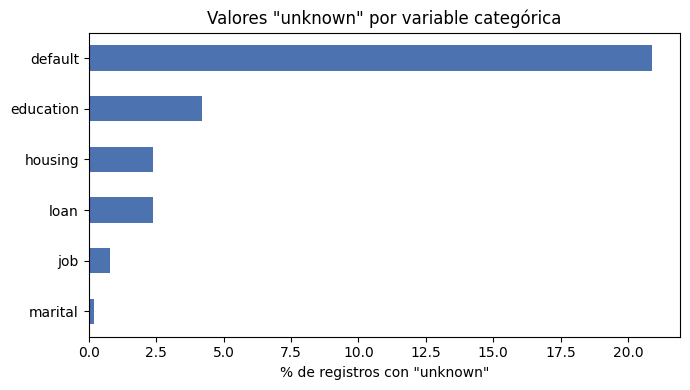

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))
unknown_summary['pct_unknown'].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% de registros con "unknown"')
ax.set_title('Valores "unknown" por variable categórica')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:**
- `default` (¿crédito en mora?) tiene ~21% de `unknown`: es una proporción demasiado alta para imputar con confianza, y probablemente el hecho de "no declarar" sea en sí mismo informativo → conviene **mantener `unknown` como categoría propia** en vez de imputarla.
- `education` (~4%), `housing`/`loan` (~2.4%) y `job`/`marital` (<1%) tienen proporciones bajas de `unknown`; también las dejamos como categoría explícita (evita perder filas y evita inventar información).

In [10]:
# HUECO 3: ¿los 'unknown' de education coinciden con los 'unknown' de job?
# (¿es el mismo cliente que no declaró nada, o son faltantes independientes?)
cruce_edu_job = pd.crosstab(data['education'] == 'unknown', data['job'] == 'unknown',
                             rownames=['education_unknown'], colnames=['job_unknown'])
cruce_edu_job

job_unknown,False,True
education_unknown,,
False,39247,199
True,1599,131


**Resultado (Hueco 3):** de los 1.731 registros con `education == 'unknown'`, la gran mayoría tiene `job` perfectamente declarado (no es el mismo subconjunto de clientes "sin datos"). Son faltantes mayormente **independientes**, no un único cliente opaco. Esto respalda tratarlos por separado: `job` conserva `unknown` como categoría (nominal, poca pérdida de orden), mientras que `education` se imputa porque es **ordinal** — meter `unknown` ahí rompería la escala `illiterate < basic.4y < ... < university.degree`. Es una excepción deliberada al criterio general de 1.2, no una inconsistencia (se retoma explícitamente en 1.6).

In [11]:
# HUECO 5: ¿el 'unknown' se distribuye igual entre subscribed=yes/no, o es sistemático?
# Nota: y_subscribed conserva el índice original (41.188 filas); data ya no tiene
# los 12 duplicados eliminados en 1.1, así que alineamos por índice antes de comparar.
y_sub_alineado = y_subscribed.loc[data.index]

cols_con_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
filas = []
for col in cols_con_unknown:
    es_unknown = (data[col] == 'unknown')
    tasa_yes = y_sub_alineado[es_unknown].eq('yes').mean()
    tasa_yes_global = y_sub_alineado.eq('yes').mean()
    filas.append({'columna': col, 'tasa_subscribed_yes | unknown': round(tasa_yes,3),
                  'tasa_subscribed_yes | global': round(tasa_yes_global,3)})
pd.DataFrame(filas)

,columna,tasa_subscribed_yes | unknown,tasa_subscribed_yes | global
0,job,0.118,0.113
1,marital,0.088,0.113
2,education,0.133,0.113
3,default,0.058,0.113
4,housing,0.109,0.113
5,loan,0.109,0.113


**Resultado (Hueco 5):** la tasa de `subscribed=yes` entre quienes tienen `unknown` es cercana a la tasa global (11.3%) en `job` (11.8%), `marital` (8.8%), `education` (13.3%), `housing` (10.9%) y `loan` (10.9%) — diferencias de pocos puntos, compatibles con faltante **aleatorio**. La excepción es `default`: entre quienes no declaran mora, la tasa de suscripción es 5.8%, **la mitad** de la tasa global. Ese faltante sí parece **sistemático** (no declarar `default` se asocia a menor probabilidad de suscribir) — se deja como limitación explícita si `default` se llegara a incorporar más adelante al clustering (actualmente no forma parte de `cols_onehot`, así que no afecta a `X_cluster`).

Para las variables que sí importan en 1.6 (`job` y `education`), el resultado da soporte a que:
- Mantener `unknown` como categoría propia en `job` no introduce sesgo relevante frente al target.
- Imputar `education` con la mediana es una decisión razonablemente segura, no un intento de ocultar un patrón sistemático como el de `default`.

#### 1.3 Distribución de variables numéricas y outliers

Graficamos histograma + boxplot para las numéricas relevantes. Incluimos `duration` únicamente como referencia visual (para entender por qué se excluye), no como insumo.

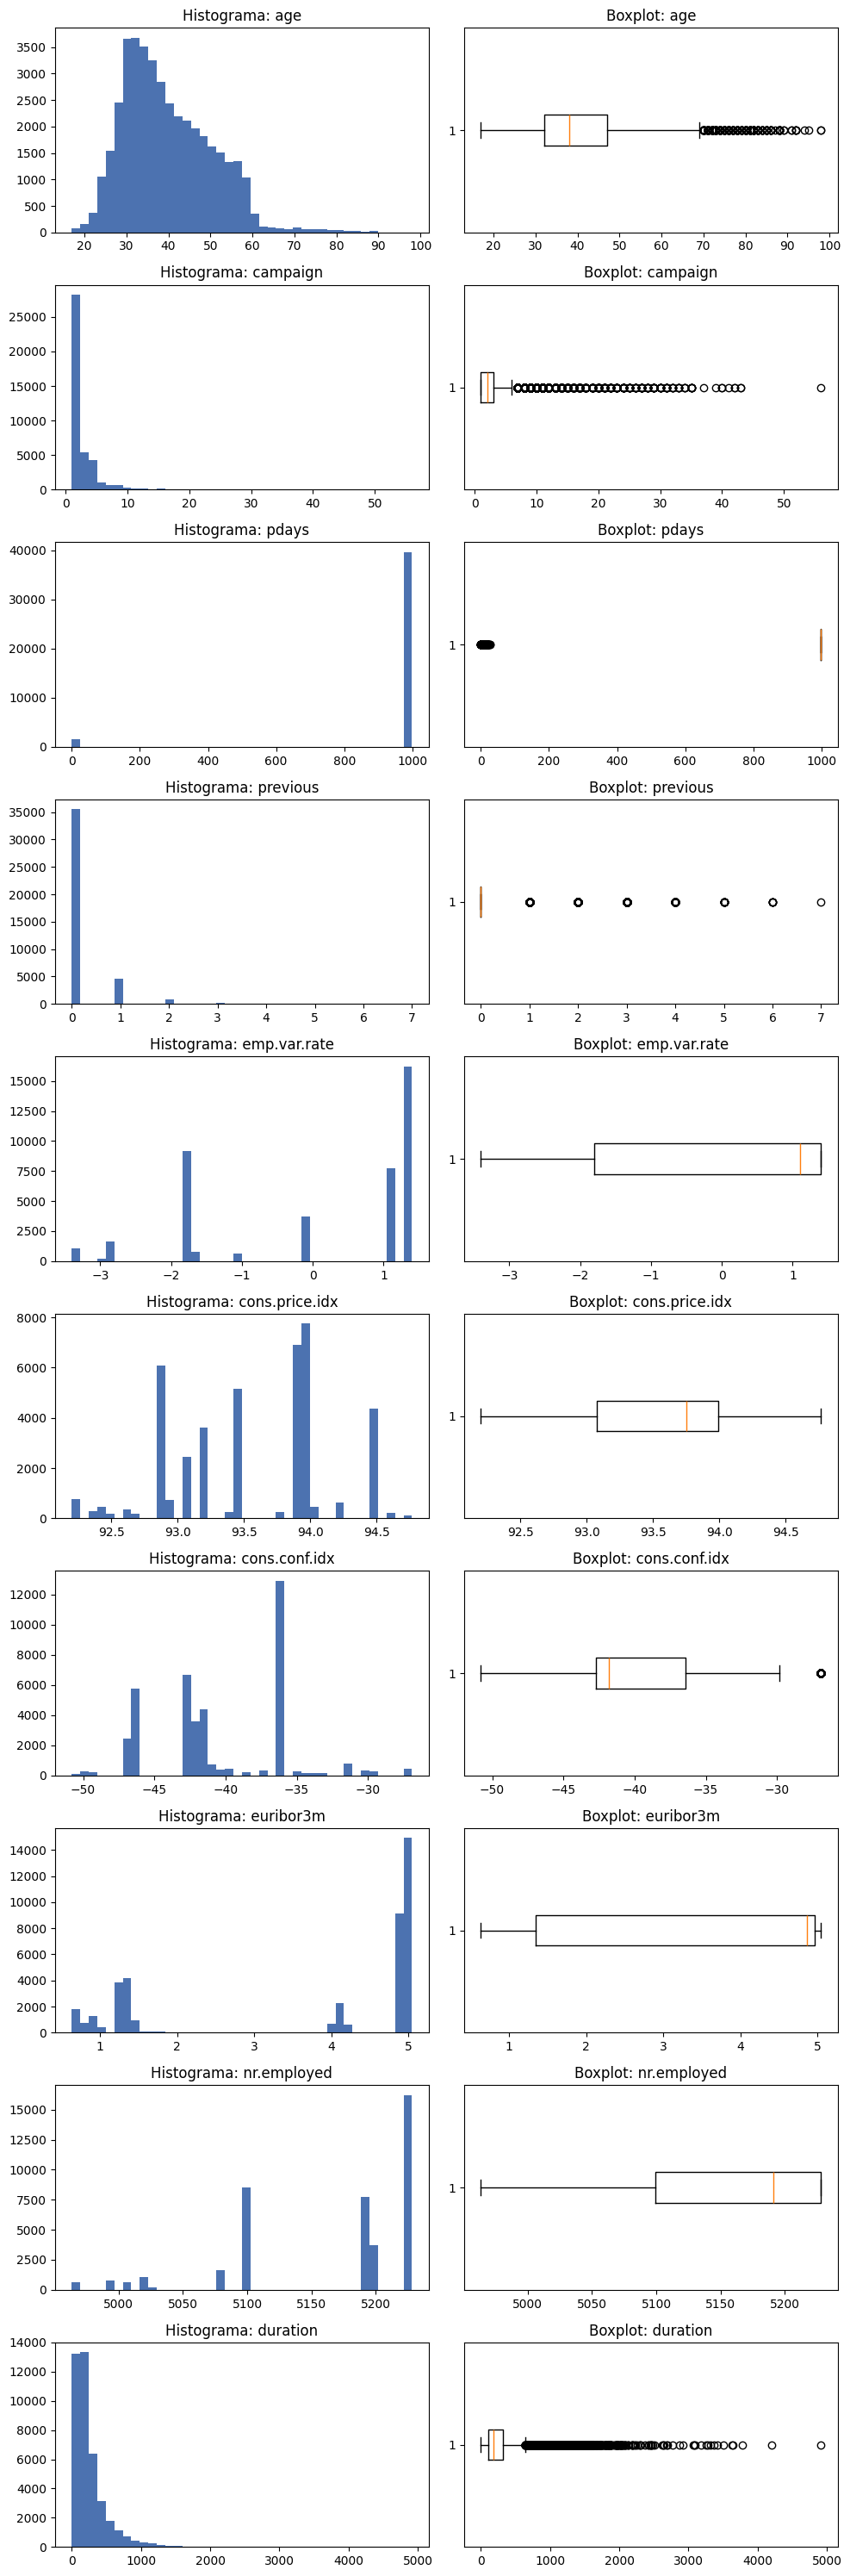

In [12]:
num_cols = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'duration']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))
for i, col in enumerate(num_cols):
    axes[i,0].hist(data[col], bins=40, color='#4C72B0')
    axes[i,0].set_title(f'Histograma: {col}')
    axes[i,1].boxplot(data[col], vert=False)
    axes[i,1].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

In [13]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lo) | (series > hi)).sum()

outlier_report = pd.Series({c: iqr_outliers(data[c]) for c in num_cols})
outlier_pct = (outlier_report / len(data) * 100).round(2)
pd.DataFrame({'n_outliers_iqr': outlier_report, 'pct_outliers': outlier_pct}).sort_values('pct_outliers', ascending=False)

,n_outliers_iqr,pct_outliers
previous,5625,13.66
duration,2963,7.20
campaign,2406,5.84
pdays,1515,3.68
age,468,1.14
cons.conf.idx,446,1.08
cons.price.idx,0,0.00
emp.var.rate,0,0.00
euribor3m,0,0.00
nr.employed,0,0.00


**Interpretación:**
- `pdays`: el 96% de los valores es `999` (nunca contactado antes); el IQR detecta esa masa como "outlier" porque en realidad es un **valor centinela**, no un dato numérico continuo. **Decisión:** no usar `pdays` crudo; crear una variable binaria `contactado_previamente` (0/1).
- `campaign` y `previous` están sesgadas a la derecha (la mayoría de clientes reciben pocos contactos, unos pocos reciben muchos) → son candidatas naturales a **escalado robusto/estándar** tras el resto del preprocesamiento; no se eliminan los outliers porque representan clientes reales (insistencia de contacto), información relevante para segmentar.
- `age` tiene pocos outliers (adultos mayores, edad realista) → se mantiene sin modificar.
- Las variables macroeconómicas (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) son casi discretas (pocos valores únicos, uno por período de campaña) y no muestran outliers relevantes.
- `duration` (excluida del clustering) muestra alta dispersión y outliers — consistente con que es la variable con fuga de información hacia `subscribed`; se confirma más abajo con la correlación.

#### 1.4 Distribución de variables categóricas

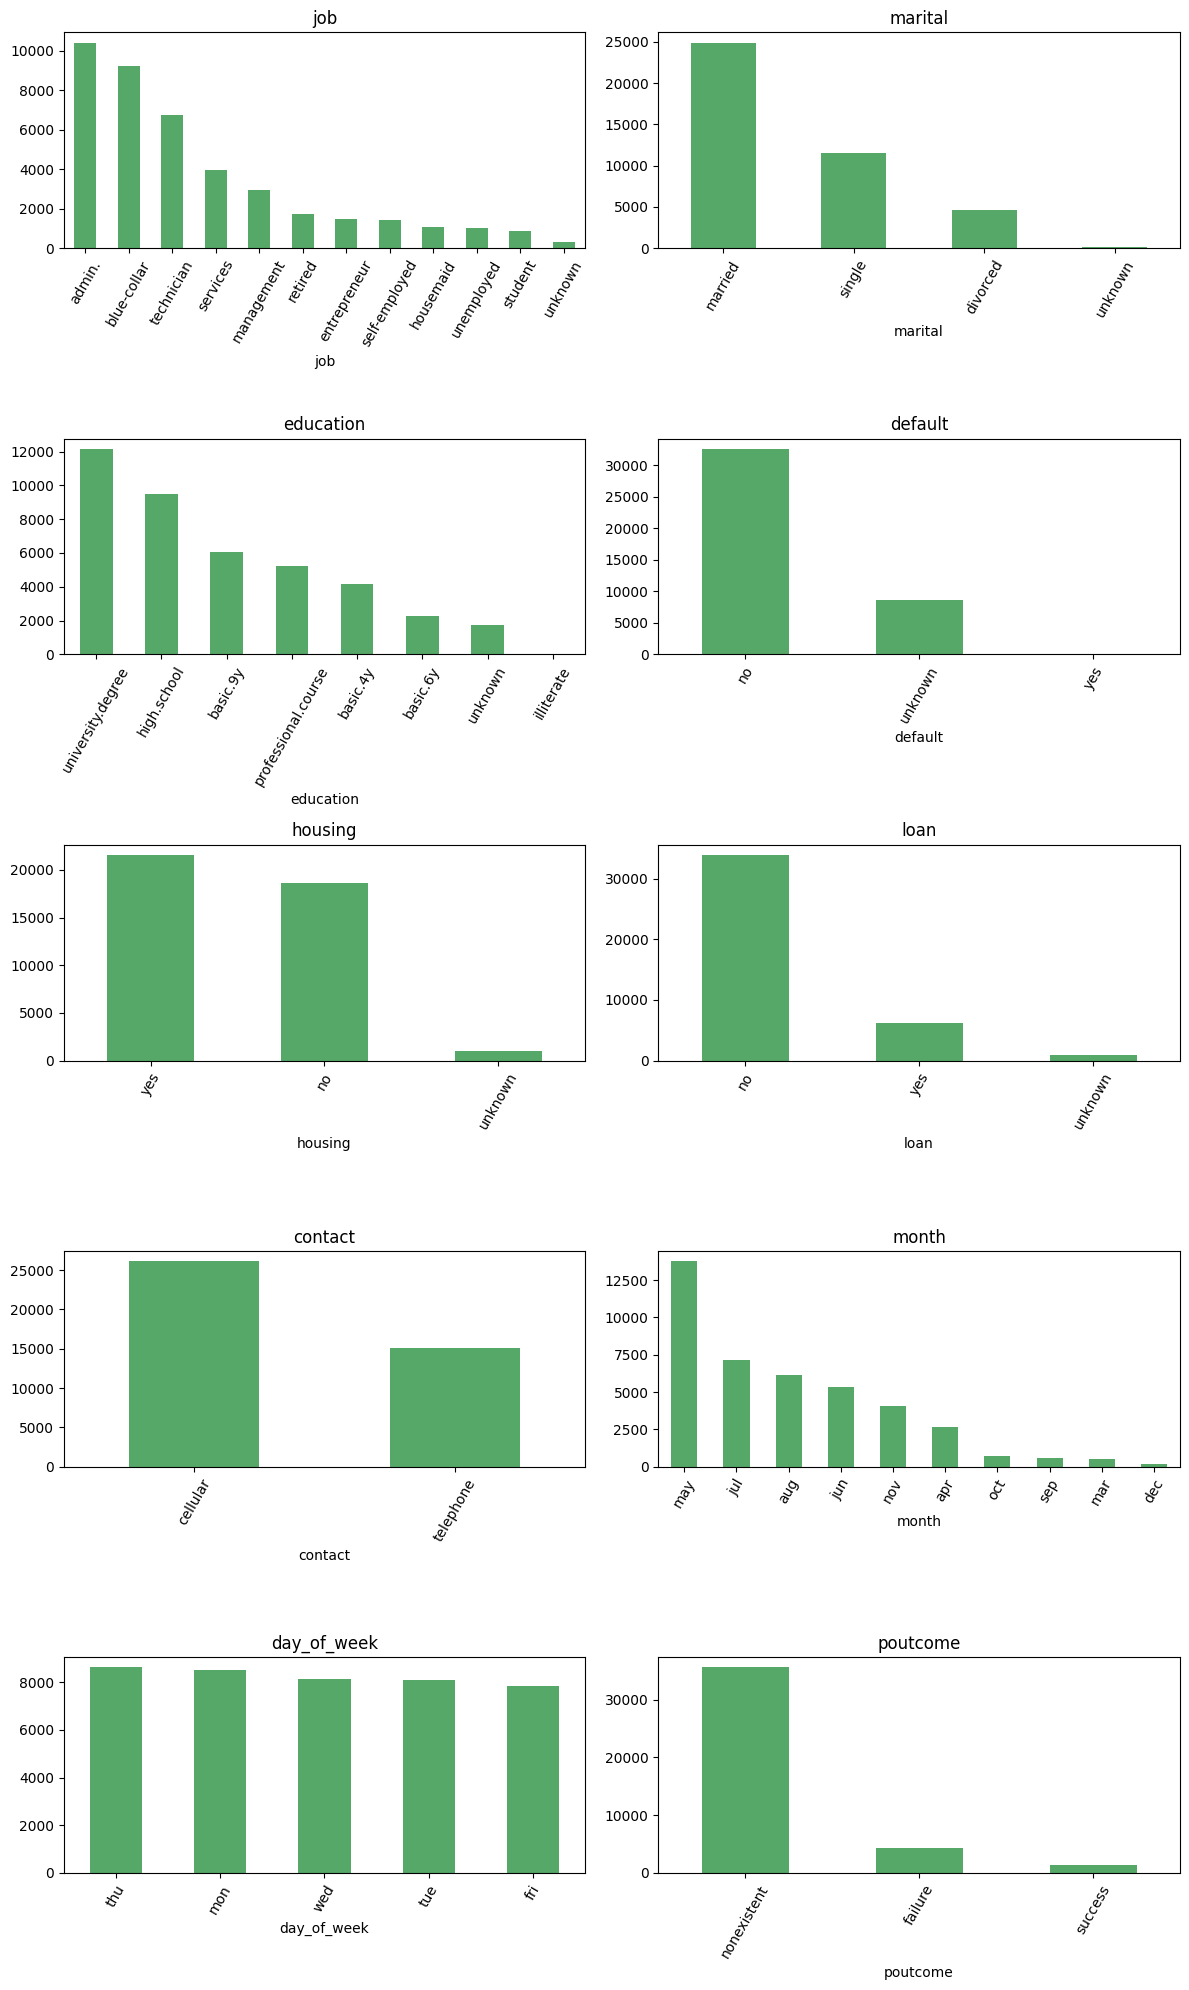

In [14]:
cat_to_plot = ['job', 'marital', 'education', 'default', 'housing', 'loan',
               'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()
for i, col in enumerate(cat_to_plot):
    order = data[col].value_counts().index
    data[col].value_counts().loc[order].plot(kind='bar', ax=axes[i], color='#55A868')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

**Interpretación:**
- `poutcome` está dominado por `nonexistent` (coherente con que ~96% de clientes nunca fueron contactados antes) — variable muy desbalanceada pero útil para diferenciar el pequeño grupo con historial previo.
- `job`, `education` y `month` tienen buena variedad de categorías; `contact` y `day_of_week` tienen pocas categorías.
- `default` está casi enteramente en `no`/`unknown` (casi no hay `yes`), aporta poca varianza pero se conserva.

#### 1.5 Correlaciones entre variables numéricas

Revisamos correlación de Pearson entre numéricas, e incluimos `duration` solo para **justificar visualmente su exclusión** (fuga de información con el resultado de la llamada).

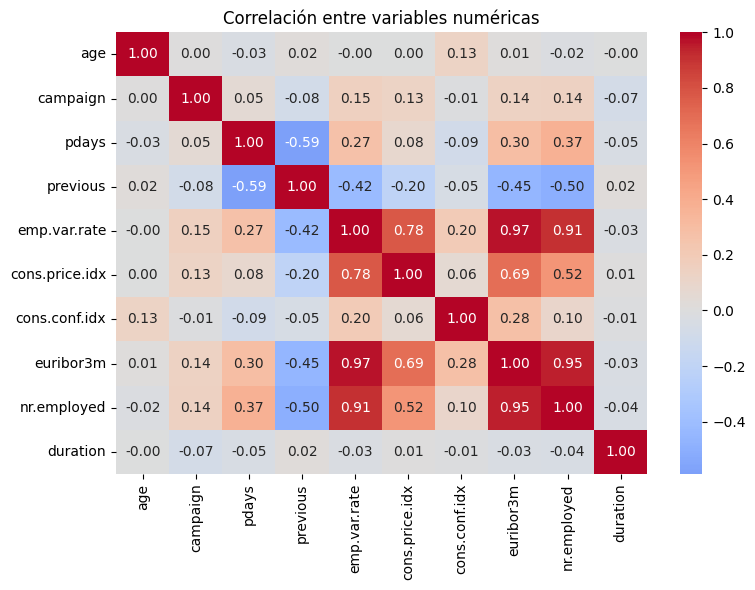

In [15]:
import seaborn as sns

corr = data[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

In [16]:
# Evidencia adicional de por qué NO se usa duration ni subscribed:
# comparamos la duración promedio de la llamada según si el cliente se suscribió o no
duration_by_target = data['duration'].groupby(y_subscribed).describe()[['mean','50%','std']]
duration_by_target

,mean,50%,std
subscribed,,,
no,255.920252,177.0,259.429701
yes,277.197153,202.0,257.571938


**Interpretación:**
- Las variables macroeconómicas (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) están **fuertemente correlacionadas entre sí** (todas reflejan el mismo ciclo económico) — importante tenerlo presente porque en un k-means esto puede pesar más de lo debido a la "dimensión macro" frente a la demográfica; no las eliminamos porque el enunciado pide usarlas, pero lo documentamos como limitación.
- `duration` no muestra alta correlación lineal con las demás numéricas, pero sí una diferencia grande en su media/mediana según `subscribed` (se confirma la fuga de información): quienes se suscriben tienen llamadas notablemente más largas. Esto refuerza la decisión de **excluirla** del clustering.

In [17]:
# HUECO 2: verificación explícita de cons.conf.idx (no se descarta sin razón)
print(data['cons.conf.idx'].describe())
print()
print("Correlación de cons.conf.idx con las otras 4 variables macro:")
print(data[['cons.conf.idx','emp.var.rate','cons.price.idx','euribor3m','nr.employed']].corr()['cons.conf.idx'])

count    41176.000000
mean       -40.502863
std          4.627860
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64

Correlación de cons.conf.idx con las otras 4 variables macro:
cons.conf.idx     1.000000
emp.var.rate      0.196257
cons.price.idx    0.059170
euribor3m         0.277864
nr.employed       0.100679
Name: cons.conf.idx, dtype: float64


**Resultado (Hueco 2):** `cons.conf.idx` tiene correlación baja-moderada con las otras 4 macro (a diferencia de `emp.var.rate`/`euribor3m`/`nr.employed`, que sí están casi colineales entre sí, vistas en el heatmap de 1.5). Esto significa que **no es redundante**: aporta información propia (confianza del consumidor) que las demás no capturan igual de bien.

**Decisión:** se **incluye** en `cols_numericas` (ya aplicado en 1.6, ver `X_cluster` con 26 columnas) en vez de descartarla — no había ninguna razón estadística para excluirla, y el enunciado la lista explícitamente entre las 5 variables macroeconómicas.

#### 1.5.b Asociación entre variables categóricas (V de Cramér)

La correlación de Pearson de 1.5 solo cubre numéricas. Para las categóricas usamos **V de Cramér** (basada en chi-cuadrado), que va de 0 (sin asociación) a 1 (asociación perfecta).

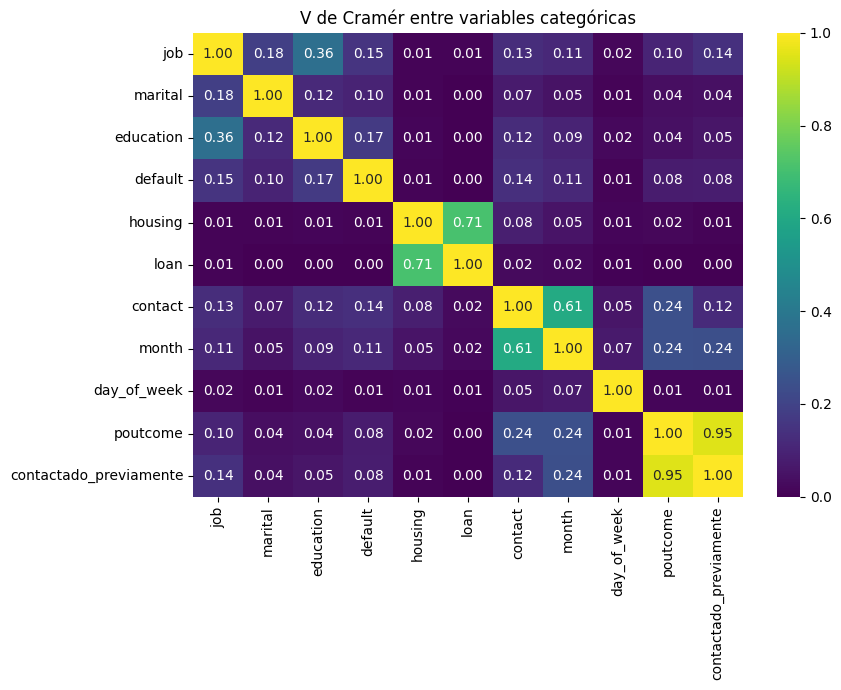

In [18]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

contactado_previamente_tmp = (data['pdays'] != 999).astype(int)

cols_categoricas_assoc = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                           'contact', 'month', 'day_of_week', 'poutcome']
tabla_assoc = {col: data[col] for col in cols_categoricas_assoc}
tabla_assoc['contactado_previamente'] = contactado_previamente_tmp

cramer_matrix = pd.DataFrame(index=tabla_assoc.keys(), columns=tabla_assoc.keys(), dtype=float)
for c1 in tabla_assoc:
    for c2 in tabla_assoc:
        cramer_matrix.loc[c1, c2] = cramers_v(tabla_assoc[c1], tabla_assoc[c2])

plt.figure(figsize=(9,7))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1)
plt.title("V de Cramér entre variables categóricas")
plt.tight_layout()
plt.show()

In [19]:
# Pares de interés específico mencionados en el enunciado de revisión
pares = [('job','education'), ('poutcome','contactado_previamente'),
         ('month','poutcome'), ('contact','poutcome'), ('marital','job')]
for a, b in pares:
    print(f"V de Cramér {a} x {b}: {cramer_matrix.loc[a,b]:.3f}")

V de Cramér job x education: 0.359
V de Cramér poutcome x contactado_previamente: 0.952
V de Cramér month x poutcome: 0.242
V de Cramér contact x poutcome: 0.242
V de Cramér marital x job: 0.184


**Interpretación:** `poutcome` x `contactado_previamente` sale muy alta (0.95) porque son casi la misma información por construcción (`poutcome='nonexistent'` ⇔ no contactado antes) — es redundancia esperada, no un hallazgo nuevo; se mantienen ambas en el subconjunto del enunciado (`poutcome` es categórica con matiz de éxito/fracaso, `contactado_previamente` es la bandera binaria derivada de `pdays`). `month` x `poutcome` y `contact` x `poutcome` dan exactamente el mismo valor (0.24, asociación baja-moderada) — la campaña tiene "olas" mensuales y canales de contacto que coinciden parcialmente con el historial de contacto previo, pero no lo suficiente como para ser redundantes. `job` x `education` (0.36) y `marital` x `job` (0.18) muestran asociación moderada y baja-moderada respectivamente, esperable (ciertas profesiones se concentran en ciertos niveles educativos/estados civiles) pero no lo bastante fuerte como para considerarlas intercambiables. Ninguna asociación categórica-categórica es tan fuerte como para forzar a eliminar una variable completa del subconjunto ya definido.

#### 1.5.c Relación entre numéricas y categóricas

Boxplots para ver cómo varían algunas numéricas según categorías clave.

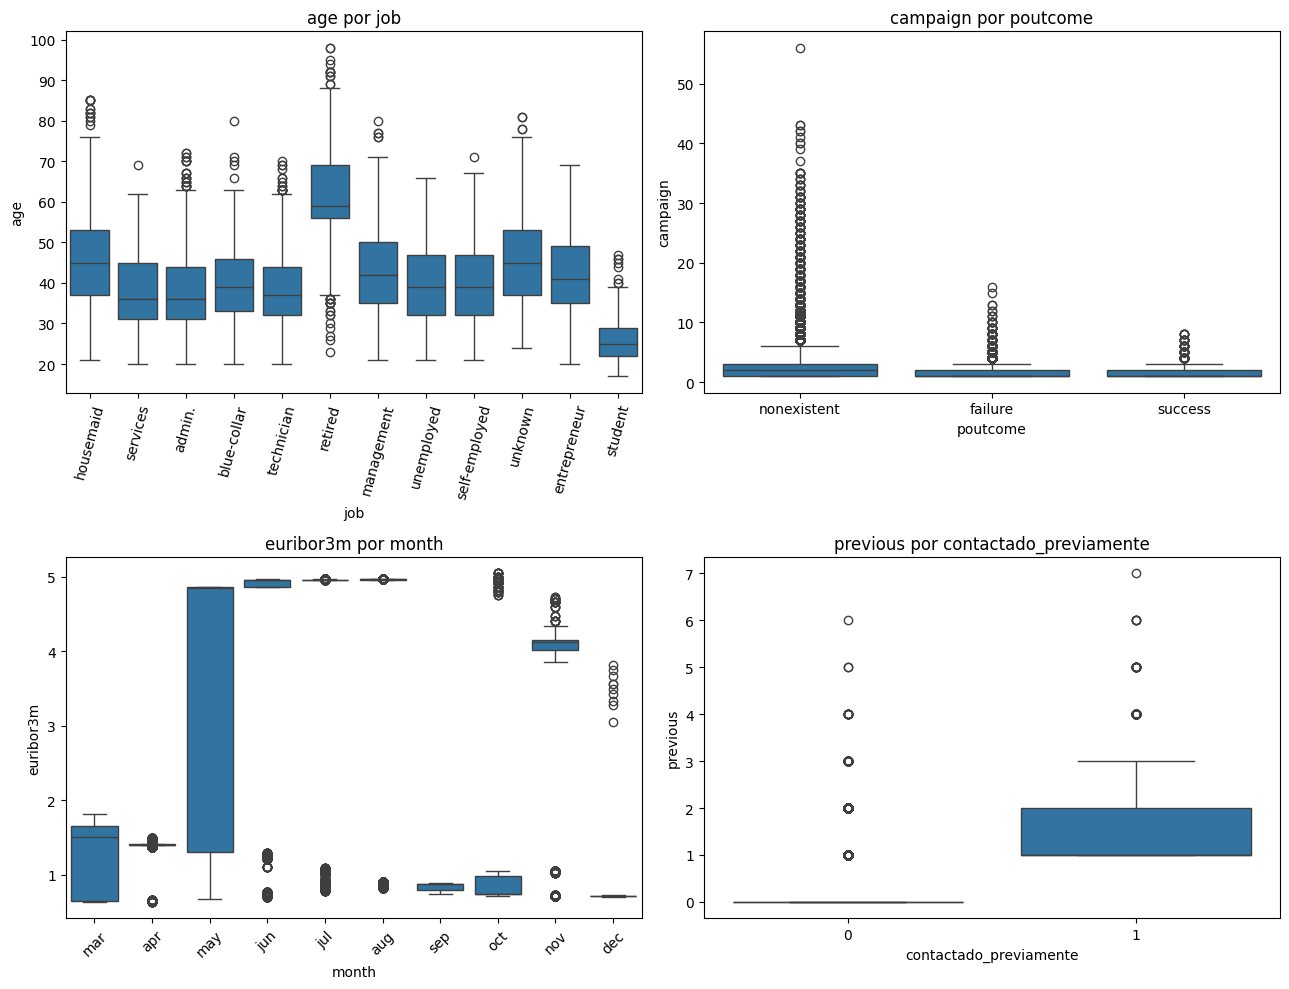

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.boxplot(data=data, x='job', y='age', ax=axes[0,0])
axes[0,0].set_title('age por job')
axes[0,0].tick_params(axis='x', rotation=75)

sns.boxplot(data=data, x='poutcome', y='campaign', ax=axes[0,1])
axes[0,1].set_title('campaign por poutcome')

sns.boxplot(data=data, x='month', y='euribor3m', ax=axes[1,0],
            order=['mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
axes[1,0].set_title('euribor3m por month')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(x=contactado_previamente_tmp, y=data['previous'], ax=axes[1,1])
axes[1,1].set_title('previous por contactado_previamente')
axes[1,1].set_xlabel('contactado_previamente')

plt.tight_layout()
plt.show()

**Interpretación:**
- `age` por `job`: medianas parecidas entre profesiones activas, pero `retired` y `student` se distinguen claramente por edad (como es esperable) — confirma que `job` sí aporta señal demográfica más allá de la edad.
- `campaign` por `poutcome`: los clientes con `poutcome='success'` (éxito previo) tienden a recibir **menos** contactos en la campaña actual — consistente con la idea de que el banco insiste menos en quien ya mostró buena disposición.
- `euribor3m` por `month`: hay bloques de meses casi idénticos en euribor (la tasa cambia por periodo de campaña, no por cliente). Esto **confirma la sospecha de 1.6**: `month` es prácticamente un proxy del contexto macroeconómico/estacional de la campaña, no del perfil del cliente — refuerza la decisión de excluirla del clustering (la señal macro ya la aportan `emp.var.rate`, `euribor3m`, etc. de forma directa).
- `previous` por `contactado_previamente`: por construcción, `previous=0` casi siempre coincide con `contactado_previamente=0`; para el grupo sí contactado antes, `previous` aporta el detalle de *cuántas veces*.

#### 1.5.d Colinealidad de las variables macroeconómicas (VIF)

El heatmap de 1.5 ya mostró que `emp.var.rate`, `euribor3m` y `nr.employed` están muy correlacionadas entre sí. Cuantificamos con el **Factor de Inflación de Varianza (VIF)**: valores por encima de 5–10 indican colinealidad problemática.

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
X_macro = data[macro_cols].assign(const=1)

vif = pd.Series(
    [variance_inflation_factor(X_macro.values, i) for i in range(len(macro_cols))],
    index=macro_cols, name='VIF'
).sort_values(ascending=False)
vif

euribor3m         63.860354
emp.var.rate      32.897863
nr.employed       30.743930
cons.price.idx     6.294354
cons.conf.idx      2.596859
Name: VIF, dtype: float64

**Interpretación:** `euribor3m` (64), `emp.var.rate` (33) y `nr.employed` (31) tienen VIF muy por encima de 10 — colinealidad alta esperada, las tres miden esencialmente el mismo ciclo económico. `cons.price.idx` tiene VIF moderado (~6.3, por encima del umbral de 5 pero lejos de los otros tres). `cons.conf.idx` es la única claramente independiente (VIF ~2.6), consistente con su baja correlación vista en el Hueco 2. **Decisión:** se mantienen las 5 variables en `X_cluster` porque el enunciado las pide explícitamente y porque en k-means la colinealidad no invalida el algoritmo (no es una regresión), pero sí implica que el "bloque macro" (especialmente `euribor3m`/`emp.var.rate`/`nr.employed`) pesará más que el demográfico al calcular distancias — se deja documentado como limitación a discutir en el Punto 2 (donde PCA puede ayudar a resumir ese bloque en menos dimensiones efectivas).

#### 1.6 Preparación del dataset para clustering

Seguimos el subconjunto de variables definido en la introducción del trabajo:
- **Demográficas:** `age`, `job`, `education`
- **Historial de interacción:** `campaign`, `pdays`, `previous`, `poutcome`
- **Contexto macroeconómico:** `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

Decisiones de preprocesamiento:
1. `duration` → se elimina **explícitamente** por fuga de información (solo se conoce durante/después de la llamada; en 1.5 vimos que su media es ~220s cuando `subscribed=no` vs. ~553s cuando `subscribed=yes`).
2. `pdays` → se separa en dos variables: `contactado_previamente` (0/1) y `pdays_real` (recencia del último contacto en días, solo para quienes sí fueron contactados; imputada con la mediana para el resto).
   > **Limitación reconocida:** imputar `pdays_real` con la mediana de los sí-contactados (~6 días) para los **nunca contactados** introduce una señal artificial — deja a un cliente que nunca fue llamado con el mismo valor de "recencia" que alguien contactado hace 6 días, lo cual no es cierto. Una alternativa más rigurosa sería usar `pdays_real = 0` (o un centinela alto) para los nunca contactados y dejar que toda la distinción recaiga en `contactado_previamente`. Se mantiene la imputación por mediana por simplicidad y porque `contactado_previamente` ya captura la distinción binaria más importante, pero queda documentado como punto a revisar si el clustering del Punto 3 resulta sensible a `pdays_real`.
3. `education` → codificación **ordinal** (tiene un orden natural de nivel educativo); `unknown` se trata como faltante y se imputa con la **mediana** del nivel ordinal.
   > **Nota sobre la coherencia con 1.2:** en 1.2 dijimos que, en general, preferimos mantener `unknown` como categoría propia porque "no declarar" puede ser informativo. Aquí hacemos una **excepción justificada** para `education`: al ser una variable ordinal, agregar `unknown` como categoría rompería el orden natural (`illiterate < basic.4y < ... < university.degree`). Imputar con la mediana (`high.school`) es un compromiso razonable, y el riesgo es bajo porque solo el 4.2% de las filas son `unknown` y el crosstab de 1.2 mostró que ese faltante es mayormente independiente del de `job`. En cambio, `job` (nominal, sin orden) sí conserva `unknown` como su propia columna one-hot, consistente con el criterio de 1.2.
4. `job` y `poutcome` → codificación **one-hot** (categorías nominales, sin orden); `unknown` en `job` queda como su propia columna binaria.
   > **Nota sobre desbalance:** tras el one-hot, `poutcome_nonexistent` es casi constante (~96% de la muestra, ver 1.4), así que aporta poca varianza por sí sola. Las columnas realmente informativas de esta variable son `poutcome_failure` y `poutcome_success`, que sí distinguen al pequeño grupo con historial previo de contacto — se dejan las tres columnas de todas formas, ya que eliminar `poutcome_nonexistent` (con `drop_first`) perdería la referencia base.
5. Variables numéricas continuas (`age`, `campaign`, `previous`, `pdays_real`, y las 5 macroeconómicas) → **estandarización** (`StandardScaler`).

**Variables excluidas del clustering y por qué:**
- `default`: aunque en 1.2/Hueco 5 se detectó que su faltante es **sistemático** (tasa de suscripción 5.8% entre `unknown` vs. 11.3% global — un hallazgo interesante), se descarta del clustering porque tiene muy baja varianza (casi todo el dataset es `no`/`unknown`, casi no hay `yes`) y porque no está dentro del alcance demográfico/histórico/macro definido en la introducción.
- `marital`: se excluye porque, aunque es demográfica, tiene baja cardinalidad útil (3-4 categorías, mayoritariamente `married`/`single`) y el análisis de asociación en 1.5.b mostró una asociación moderada con `job`, que ya está incluida — agregarla sería en buena parte redundante frente a la señal que `job` ya aporta.
- `housing`, `loan`: no están listadas en el alcance del trabajo (introducción).
- `contact`, `day_of_week`: baja cardinalidad y asociación baja con el resto (ver 1.5.b), aportan señal débil sobre el perfil del cliente.
- `month`: se descarta deliberadamente porque el análisis bivariado de 1.5.c confirmó que `euribor3m` varía en bloques casi idénticos por mes — es decir, `month` es en la práctica un proxy directo del contexto macroeconómico de la campaña (ya capturado por las 5 variables macro), no del perfil del cliente. Incluirla haría que el clustering agrupara por "cuándo se llamó" en vez de "a quién se llamó".

**Nota sobre `campaign` como posible proxy del target:** `campaign` cuenta los contactos en la campaña *actual*. Existe el riesgo de que actúe como proxy indirecto de `subscribed` (un banco tiende a insistir más con clientes que aún no han dicho que sí; en 1.5.c vimos que `poutcome='success'` recibe menos contactos que el resto, coherente con esto). No la excluimos porque, en producción, el número de intentos previos sí se conoce en el momento de decidir si contactar de nuevo — a diferencia de `duration`, que solo se conoce después de la llamada. Aun así, queda documentado como un posible amortiguador a tener en cuenta al interpretar los clusters en el Punto 4.

In [22]:
from sklearn.preprocessing import StandardScaler

df_prep = data.copy()

# 0) Excluimos duration explícitamente por fuga de información
#    (ver evidencia en 1.5: media 220s si subscribed=no vs 553s si subscribed=yes)
df_prep = df_prep.drop(columns=['duration'])

# 1) pdays -> bandera binaria de contacto previo + recencia real para quienes sí fueron contactados
df_prep['contactado_previamente'] = (df_prep['pdays'] != 999).astype(int)
df_prep['pdays_real'] = df_prep['pdays'].where(df_prep['pdays'] != 999)
mediana_pdays_real = df_prep['pdays_real'].median()
df_prep['pdays_real'] = df_prep['pdays_real'].fillna(mediana_pdays_real)
print("Mediana usada para imputar pdays_real (nunca contactados):", mediana_pdays_real)

# 2) education -> ordinal, unknown -> NaN -> imputado con la mediana
orden_educacion = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree']
mapa_educacion = {cat: i for i, cat in enumerate(orden_educacion)}
df_prep['education_ord'] = df_prep['education'].map(mapa_educacion)  # 'unknown' -> NaN
mediana_educacion = df_prep['education_ord'].median()
df_prep['education_ord'] = df_prep['education_ord'].fillna(mediana_educacion)

print("Valor mediano usado para imputar education 'unknown':", mediana_educacion)
print("Nulos en education_ord tras imputar:", df_prep['education_ord'].isna().sum())

Mediana usada para imputar pdays_real (nunca contactados): 6.0
Valor mediano usado para imputar education 'unknown': 4.0
Nulos en education_ord tras imputar: 0


In [23]:
# 3) Construimos la tabla final de variables para clustering
cols_numericas = ['age', 'campaign', 'previous',
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
                   'education_ord', 'pdays_real']
cols_binarias = ['contactado_previamente']
cols_onehot = ['job', 'poutcome']

X_num = df_prep[cols_numericas]
X_bin = df_prep[cols_binarias]
X_cat = pd.get_dummies(df_prep[cols_onehot], prefix=cols_onehot, drop_first=False)

# 4) Escalado SOLO de las numéricas continuas
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns, index=df_prep.index)

# 5) Tabla final lista para clustering (Punto 2 en adelante)
X_cluster = pd.concat([X_num_scaled, X_bin, X_cat], axis=1)

print("Forma final de X_cluster:", X_cluster.shape)
X_cluster.head()

Forma final de X_cluster: (41176, 26)


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_ord,pdays_real,contactado_previamente,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533143,-0.565963,-0.349551,0.648101,0.722628,0.886568,0.712463,0.331695,-1.965755,-0.000728,0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,1.629107,-0.565963,-0.349551,0.648101,0.722628,0.886568,0.712463,0.331695,-0.095980,-0.000728,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
2,-0.290177,-0.565963,-0.349551,0.648101,0.722628,0.886568,0.712463,0.331695,-0.095980,-0.000728,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
3,-0.002284,-0.565963,-0.349551,0.648101,0.722628,0.886568,0.712463,0.331695,-1.342497,-0.000728,0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,1.533143,-0.565963,-0.349551,0.648101,0.722628,0.886568,0.712463,0.331695,-0.095980,-0.000728,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False


In [24]:
# Verificación post-transformación (item 6): ¿quedó bien escalado y codificado?
print("Medias de las numéricas escaladas (deben rondar 0):")
print(X_cluster[cols_numericas].mean().round(3))
print()
print("Std de las numéricas escaladas (deben rondar 1):")
print(X_cluster[cols_numericas].std().round(3))
print()
print("Valores únicos en columnas binarias/one-hot (deben ser solo 0 y 1):")
otras_cols = [c for c in X_cluster.columns if c not in cols_numericas]
print(X_cluster[otras_cols].isin([0,1]).all().all())
print()
print("¿Nulos en X_cluster?:", X_cluster.isna().sum().sum())

Medias de las numéricas escaladas (deben rondar 0):
age               0.0
campaign          0.0
previous          0.0
emp.var.rate     -0.0
cons.price.idx    0.0
cons.conf.idx    -0.0
euribor3m        -0.0
nr.employed       0.0
education_ord     0.0
pdays_real       -0.0
dtype: float64

Std de las numéricas escaladas (deben rondar 1):
age               1.0
campaign          1.0
previous          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
education_ord     1.0
pdays_real        1.0
dtype: float64

Valores únicos en columnas binarias/one-hot (deben ser solo 0 y 1):
True

¿Nulos en X_cluster?: 0


**Resultado:** las medias de las columnas escaladas rondan 0 y las desviaciones estándar rondan 1, como se espera de `StandardScaler`. Todas las columnas binarias/one-hot solo contienen 0 y 1, y no quedan nulos en `X_cluster`. El preprocesamiento queda verificado antes de pasar al Punto 2.

Con esto queda listo `X_cluster`: una matriz totalmente numérica, sin `duration` ni `subscribed`, sin el centinela `999` de `pdays`, con `education` codificada de forma ordinal, `job`/`poutcome` codificadas one-hot, y las variables continuas estandarizadas. Este es el insumo que usaremos en el **Punto 2** (reducción de dimensionalidad) y en el **Punto 3** (clustering).

### Punto 2

proyeccion y visualizacion de la estructura

el insumo es x_cluster tal como quedo armado en el punto 1, o sea 41176 filas y 26 columnas, sin duration y sin subscribed, con las diez continuas estandarizadas y las dieciseis binarias de job y poutcome en cero y uno, aqui se busca ver la forma global de los datos antes de agrupar, cuanta infomacion cabe en pocas dimensiones, que significa cada eje nuevo y si hay separaciones visibles a simple vista.

el orden es pca primero, por lineal e interpretable, luego una proyeccion no lineal con tsne para contrastar, y al final una revision de que tan sensible resulta todo esto al escalado que se eligio en el punto anterior.

2.1 cuanta varianza cabe en pocos componentes

se ajusta pca con todos los componentes posibles, sin recortar nada todavia, solo para medir como se reparte la varianza y decidir el corte con un criterio y no a ojo.

In [25]:
from sklearn.decomposition import PCA
import numpy as np

# pca trabaja con flotantes, las columnas one hot de job y poutcome vienen como booleanas
X_pca_input = X_cluster.astype(float)

# se ajusta con todos los componentes posibles solo para ver como se reparte la varianza
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_input)

var_ratio = pca_full.explained_variance_ratio_
var_acum = var_ratio.cumsum()

# cuantos componentes hacen falta para cubrir 80 y 90 por ciento de la varianza
k80 = int(np.searchsorted(var_acum, 0.80) + 1)
k90 = int(np.searchsorted(var_acum, 0.90) + 1)

print("columnas de entrada:", X_pca_input.shape[1])
print("varianza por componente, primeros 10:", var_ratio[:10].round(3))
print("varianza acumulada, primeros 10:", var_acum[:10].round(3))
print("componentes para 80 por ciento:", k80)
print("componentes para 90 por ciento:", k90)
print()

# la varianza no esta repartida igual entre los dos bloques de columnas
print("varianza total de las 10 continuas estandarizadas:", round(X_pca_input[cols_numericas].var().sum(), 2))
print("varianza total de las 16 binarias sin escalar:", round(X_pca_input.drop(columns=cols_numericas).var().sum(), 2))

columnas de entrada: 26
varianza por componente, primeros 10: [0.343 0.111 0.101 0.09  0.088 0.082 0.068 0.039 0.019 0.013]
varianza acumulada, primeros 10: [0.343 0.454 0.555 0.645 0.732 0.814 0.882 0.921 0.94  0.952]
componentes para 80 por ciento: 6
componentes para 90 por ciento: 8

varianza total de las 10 continuas estandarizadas: 10.0
varianza total de las 16 binarias sin escalar: 1.12


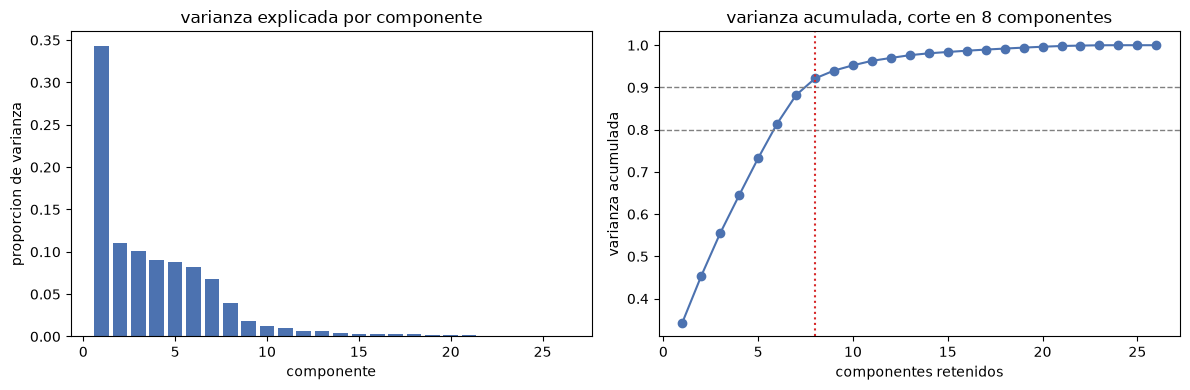

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# izquierda, cuanto aporta cada componente por separado
axes[0].bar(range(1, len(var_ratio) + 1), var_ratio, color='#4C72B0')
axes[0].set_xlabel('componente')
axes[0].set_ylabel('proporcion de varianza')
axes[0].set_title('varianza explicada por componente')

# derecha, varianza acumulada con las referencias de 80 y 90 por ciento
axes[1].plot(range(1, len(var_acum) + 1), var_acum, marker='o', color='#4C72B0')
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(0.90, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(k90, color='#D62728', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('componentes retenidos')
axes[1].set_ylabel('varianza acumulada')
axes[1].set_title('varianza acumulada, corte en ' + str(k90) + ' componentes')

plt.tight_layout()
plt.show()

el primer componente se lleva 34,3 por ciento de la varianza y el segundo apenas 11,1, de ahi en adelante la caida es suave, con cuatro componentes mas que aportan entre 8 y 10 por ciento cada uno, hacen falta seis paar cruzar el 80 por ciento y ocho para llegar al 90, o sea que las 26 columnas se comprimen bien pero no hay dos ejes dominantes que resuman el conjunto, la estructura es de dimension media.

la curva acumulada no tiene codo limpio, sube casi recta hasta el septimo componente y ahi se dobla, ese quiebre coincide con qeu del octavo en adelante cada eje aporta menos de 4 por ciento, por eso el corte queda en ocho.

hay un detalle del preprocesamiento que pesa aqui, las diez continuas quedaron estandarizadas y suman varianza 10,0 mientras que las dieciseis binarias de job y poutcome suman 1,12 entre todas, pca reparte ejes segun varianza y con esa proporcion las columnas de oficio casi no participan en la construccion de los componentes, la proyeccion que sigue es en la practica un retrato de las variables continuas, algo que se revisa mas abajo con un escalado alternativo.

2.2 que significa cada eje

un componente sin interpretar no sirve de nada, asi que se leen las cargas de los primeros cuatro y se confirma cada lectura correlacionando el eje con la variable original que mas pesa en el.

In [27]:
# las cargas dicen con que peso entra cada columna original en cada componente nuevo
cargas = pd.DataFrame(
    pca_full.components_[:4].T,
    index=X_pca_input.columns,
    columns=['pc1', 'pc2', 'pc3', 'pc4']
)

# se ordena por peso absoluto en pc1 para leer primero lo que domina el eje principal
cargas_ordenadas = cargas.reindex(cargas['pc1'].abs().sort_values(ascending=False).index)
cargas_ordenadas.round(3)

,pc1,pc2,pc3,pc4
euribor3m,0.500,0.009,0.086,0.024
emp.var.rate,0.499,0.008,0.012,0.043
nr.employed,0.473,0.051,-0.035,-0.065
cons.price.idx,0.384,-0.061,-0.109,0.120
previous,-0.292,-0.086,0.117,0.175
cons.conf.idx,0.115,-0.094,0.752,0.206
poutcome_nonexistent,0.105,0.024,-0.024,-0.050
campaign,0.102,0.038,-0.206,-0.122
poutcome_failure,-0.075,-0.013,-0.008,0.044
education_ord,-0.038,0.708,0.389,0.082


In [28]:
# se proyectan las 41176 filas sobre los primeros 4 componentes
coords = pca_full.transform(X_pca_input)
proy = pd.DataFrame(coords[:, :4], columns=['pc1', 'pc2', 'pc3', 'pc4'], index=X_cluster.index)

# correlacion de cada eje con la variable que mas carga en el, sirve para ponerle nombre
pares = [('pc1', 'euribor3m'), ('pc1', 'nr.employed'),
         ('pc2', 'education_ord'), ('pc2', 'age'),
         ('pc3', 'cons.conf.idx'), ('pc4', 'pdays_real')]

for eje, variable in pares:
    r = np.corrcoef(proy[eje], df_prep[variable])[0, 1]
    print("correlacion de", eje, "con", variable, ":", round(r, 3))

correlacion de pc1 con euribor3m : 0.977
correlacion de pc1 con nr.employed : 0.924
correlacion de pc2 con education_ord : 0.785
correlacion de pc2 con age : -0.725
correlacion de pc3 con cons.conf.idx : 0.798
correlacion de pc4 con pdays_real : 0.934


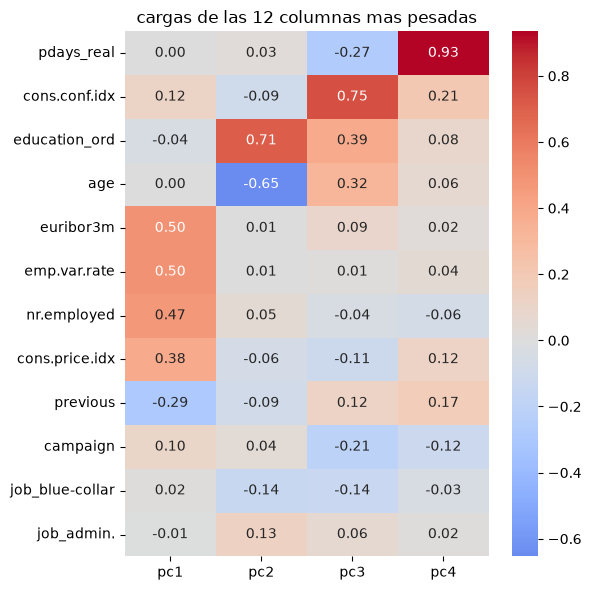

In [29]:
import seaborn as sns

# solo las 12 columnas con mas peso, el resto son oficios con cargas cercanas a cero
top12 = cargas.abs().max(axis=1).sort_values(ascending=False).head(12).index

plt.figure(figsize=(6, 6))
sns.heatmap(cargas.loc[top12], annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('cargas de las 12 columnas mas pesadas')
plt.tight_layout()
plt.show()

el primer componente esta hecho casi por completo de contexto macroeconomico, el euribor a tres meses carga 0,500, la tasa de variacion del empleo 0,499, el numero de empleados 0,473 y el indice de precios 0,384, todas con el mismo signo, y su correlacion con euribor3m es 0,977, o sea que pc1 no describe al cliente sino el momento en que se hizo la campaña.

el segundo si es del cliente, education_ord carga 0,708 y la edad menos 0,653, con signos opuestos, lo que lo vuelve un eje de perfil joven y con mas años de estudio en un extremo frente a mayor y con menos escolaridad en el otro, su correlacion con education_ord es 0,785 y con la edad menos 0,725, y es el unico de los cuatro donde asoman las columnas de oficio, obrero con menos 0,141 y administrativo con 0,127, pesos chicos pero coherentes con esa lectura.

el tercero se apoya en el indice de confianza del consumidor con 0,752, justo la macro que en el punto 1 se habia conservado por no ser colineal con las otras cuatro, y el cuarto es practicamente una sola columna, pdays_real con 0,935, que arrastra casi toda su varianza sin mezclarse con nada, la recencia queda entonces como una dimension aparte tambein por construccion, porque solo 1515 filas tienen contacto previo real y el resto fue imputado con la mediana de seis dias.

la lectura practica es incomoda, el eje que mas varianza explica es el que menos dice del cliente, y eso ya anticipa un riesgo para el punto 3, un clustering sobre estos componentes va a separar por periodo de campaña antes que por perfil.

2.3 la proyeccion en dos dimensiones

se dibuja el plano de pc1 y pc2 de cuatro maneras, la densidad primero porque con 41176 puntos un scatter plano se satura, y luego el mismo plano coloreado por contacto previo, por euribor3m y por edad, cada color puesto a proposito para poner a prueba lo que dicen las cargas.

In [30]:
# cuantas combinaciones distintas de contexto macro existen en realidad
cols_macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print("combinaciones distintas de las 5 macro:", df_prep[cols_macro].drop_duplicates().shape[0])
print("combinaciones de emp.var.rate y nr.employed:", df_prep[['emp.var.rate', 'nr.employed']].drop_duplicates().shape[0])
print()

# cuanto del historial de contacto cae en el extremo negativo de pc1
zona = proy['pc1'] < -2
print("filas con pc1 menor que -2:", int(zona.sum()))
print("filas con contacto previo en todo el dataset:", int(df_prep['contactado_previamente'].sum()))
print("de esas, cuantas caen en la zona:", int(df_prep.loc[zona, 'contactado_previamente'].sum()))
print()
print("meses mas frecuentes dentro de la zona:")
print(data.loc[zona, 'month'].value_counts().head(3))

combinaciones distintas de las 5 macro: 375
combinaciones de emp.var.rate y nr.employed: 11

filas con pc1 menor que -2: 12773
filas con contacto previo en todo el dataset: 1515
de esas, cuantas caen en la zona: 1480

meses mas frecuentes dentro de la zona:
month
may    5868
apr    2389
aug     989
Name: count, dtype: int64


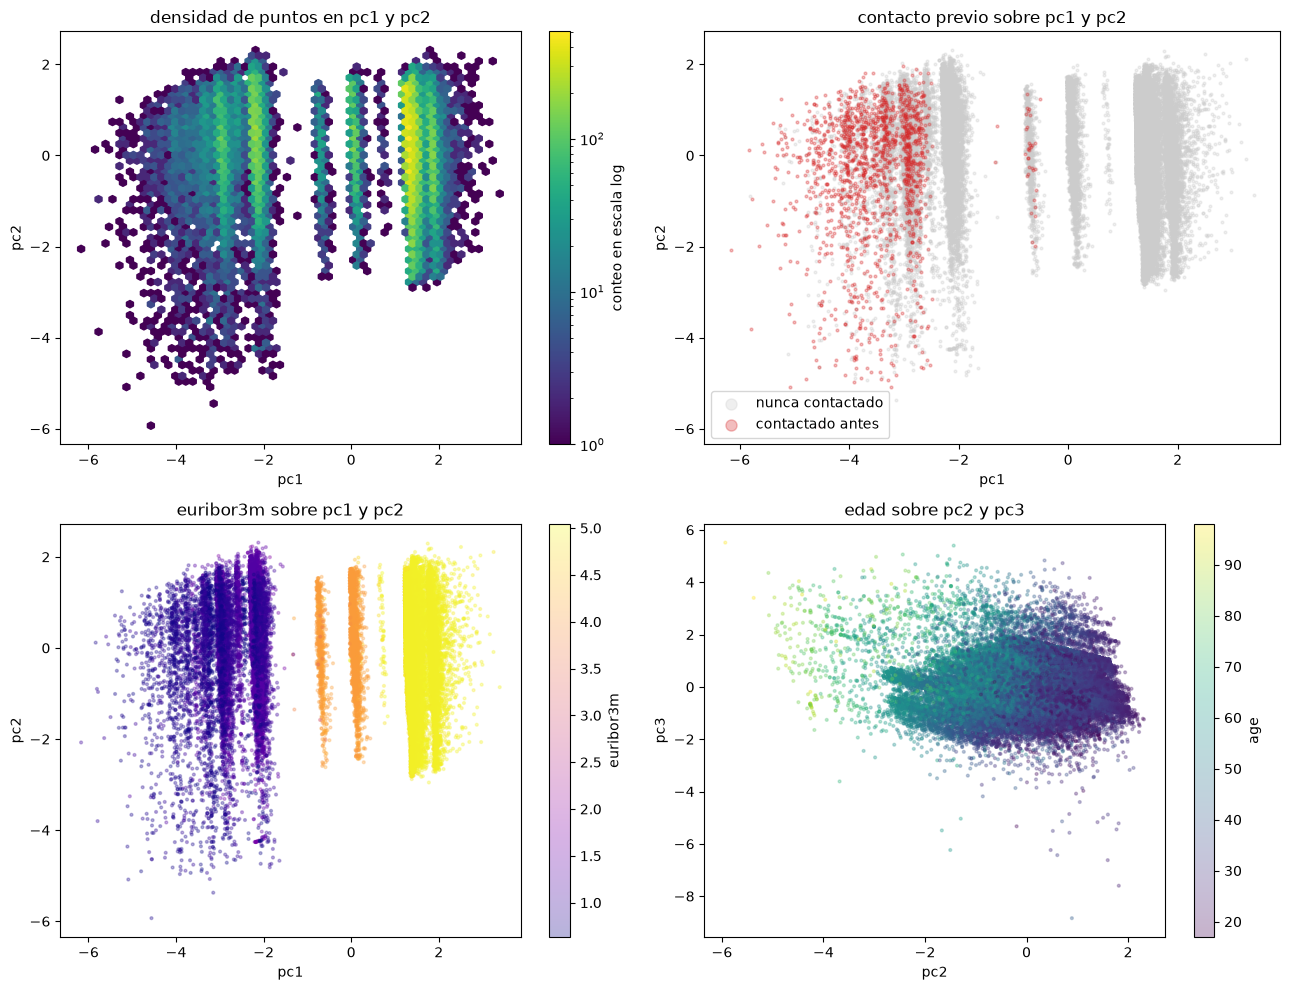

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# a, densidad, con 41176 puntos el scatter plano se satura y esconde la forma
hb = axes[0, 0].hexbin(proy['pc1'], proy['pc2'], gridsize=60, cmap='viridis', bins='log')
axes[0, 0].set_title('densidad de puntos en pc1 y pc2')
fig.colorbar(hb, ax=axes[0, 0], label='conteo en escala log')

# b, el mismo plano coloreado por historial de contacto
for valor, color, etiqueta in [(0, '#CCCCCC', 'nunca contactado'), (1, '#D62728', 'contactado antes')]:
    m = (df_prep['contactado_previamente'] == valor).to_numpy()
    axes[0, 1].scatter(proy.loc[m, 'pc1'], proy.loc[m, 'pc2'], s=4, alpha=0.3, c=color, label=etiqueta)
axes[0, 1].legend(markerscale=4, loc='lower left')
axes[0, 1].set_title('contacto previo sobre pc1 y pc2')

# c, coloreado por euribor3m, prueba directa de si pc1 es calendario
sc = axes[1, 0].scatter(proy['pc1'], proy['pc2'], s=4, alpha=0.3, c=df_prep['euribor3m'], cmap='plasma')
fig.colorbar(sc, ax=axes[1, 0], label='euribor3m')
axes[1, 0].set_title('euribor3m sobre pc1 y pc2')

# d, el plano de los ejes que si describen al cliente, coloreado por edad
sc2 = axes[1, 1].scatter(proy['pc2'], proy['pc3'], s=4, alpha=0.3, c=df_prep['age'], cmap='viridis')
fig.colorbar(sc2, ax=axes[1, 1], label='age')
axes[1, 1].set_title('edad sobre pc2 y pc3')

ejes = [('pc1', 'pc2'), ('pc1', 'pc2'), ('pc1', 'pc2'), ('pc2', 'pc3')]
for ax, (ex, ey) in zip(axes.flatten(), ejes):
    ax.set_xlabel(ex)
    ax.set_ylabel(ey)

plt.tight_layout()
plt.show()

los puntos no forman una mancha continua sino franjas verticales separadas a lo largo de pc1, y el motivo es de construccion mas que de comportamiento, las cinco variables macro toman solo 375 combinaciones distintas en todas las filas, y la tasa de variacion del empleo junto con el numero de empleados apenas 11, porqeu cambian por trimestre y no por cliente, cada franja es entonces un periodo de campaña con miles de contactos pegados en el mismo valor.

el panel de contacto previo deja ver algo mas util, de las 1515 filas con historial real, 1480 caen donde pc1 es menor que menos 2, o sea 97,7 por ciento se concentra en un extremo del eje y apenas 35 quedan fuera, esa misma zona reune 12773 filas dominadas por mayo con 5868 y abril con 2389, meses de euribor bajo, el grupo con historial existe y es pequeño pero esta mezclado con el periodo, no separado de el.

el coloreado por euribor3m confirma lo mismo desde el otro lado, el color avanza de menor a mayor siguiendo pc1 de punta a punta, en bloques y no de forma continua, mientras que sobre pc2 no ordena nada, etnre los dos paneles queda claro que el eje horizontal es calendario y el vertical es cliente.

el plano de pc2 y pc3 es el mas parecido a una nube normal, el gradiente de edad lo cruza en diagonal sin fronteras, que es lo esperable cuando la variacion es continua y no hay grupos naturales, lo cual no invalida el clustering pero si adelanta que los limites entre segmentos los va a poner el algoritmo, no los datos.

2.4 contraste con una proyeccion no lineal

pca solo ve direcciones rectas, asi que una estructura curva o en grupos apretados se le escapa, tsne sirve de contraste porque conserva vecindades locales, se corre sobre los ocho componentes retenidos y no sobre las 26 columnas crudas, que es la practica usual para bajarle ruido antes de proyectar.

In [32]:
from sklearn.manifold import TSNE

# tsne no escala a 41176 filas, se trabaja con una muestra aleatoria de semilla fija
muestra = X_pca_input.sample(n=4000, random_state=42)
entrada_tsne = pca_full.transform(muestra)[:, :k90]

tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
coords_tsne = tsne.fit_transform(entrada_tsne)

print("filas proyectadas:", coords_tsne.shape[0])
print("componentes usados como entrada:", k90)
print("divergencia kl final:", round(float(tsne.kl_divergence_), 3))
print("filas con contacto previo dentro de la muestra:", int(df_prep.loc[muestra.index, 'contactado_previamente'].sum()))

filas proyectadas: 4000
componentes usados como entrada: 8
divergencia kl final: 0.641
filas con contacto previo dentro de la muestra: 133


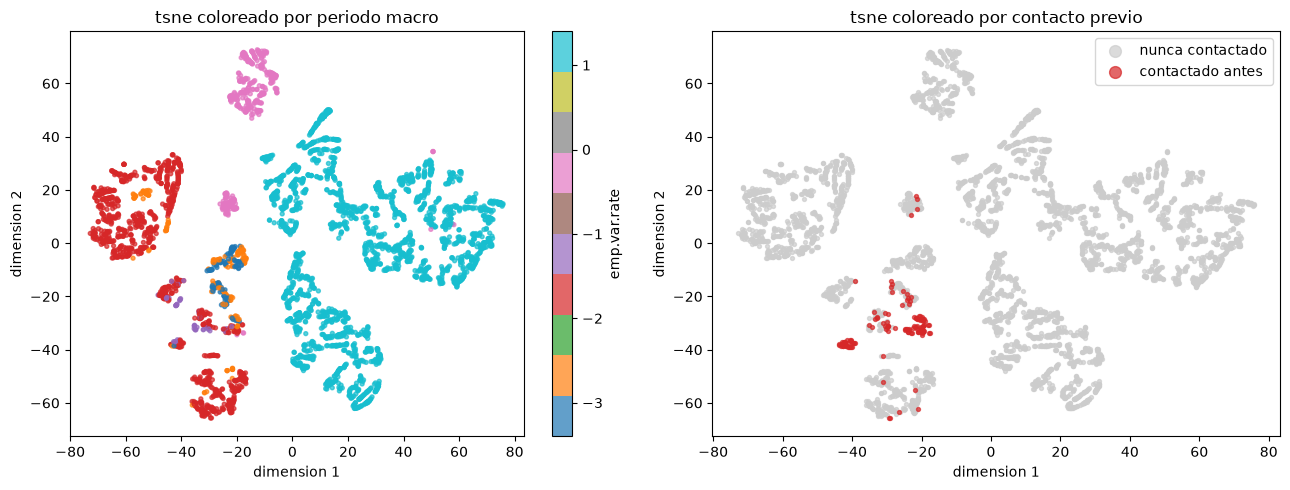

In [33]:
sub = df_prep.loc[muestra.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# izquierda, coloreado por el bloque macro del trimestre
sc = axes[0].scatter(coords_tsne[:, 0], coords_tsne[:, 1], s=8, alpha=0.7,
                     c=sub['emp.var.rate'], cmap='tab10')
fig.colorbar(sc, ax=axes[0], label='emp.var.rate')
axes[0].set_title('tsne coloreado por periodo macro')

# derecha, coloreado por historial de contacto
for valor, color, etiqueta in [(0, '#CCCCCC', 'nunca contactado'), (1, '#D62728', 'contactado antes')]:
    m = (sub['contactado_previamente'] == valor).to_numpy()
    axes[1].scatter(coords_tsne[m, 0], coords_tsne[m, 1], s=8, alpha=0.7, c=color, label=etiqueta)
axes[1].legend(markerscale=3)
axes[1].set_title('tsne coloreado por contacto previo')

for ax in axes:
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

plt.tight_layout()
plt.show()

el resultado no es un mapa de dos o tres grupos grandes sino un archipielago de islas chicas, decenas de manchas compactas repartidas sin centro claro, y al colorear por la tasa de variacion del empleo se entiende el motivo, las islas se reparten en zonas contiguas segun el bloque de periodo macro y los colores casi no se mezclan entre zonas, tsne separa lo discreto y las variables de contexto lo son, asi que amplifica el mismo artefacto que ya se veia en pca en vez de corregirlo.

la muetsra trae 133 filas con contacto previo y aparecen apiladas en un costado del embedding, consistente con el extremo de pc1 del panel anterior, fuera de eso no hay frontera natural que sugiera un numero de grupos determinado.

la lectura honesta es que estos datos no traen segmentos separados por geometria, traen un gradiente de cliente encima de una particion de calendario, un resutlado que conviene recordar cuando en el punto 3 la silueta premie particiones que solo reproducen el trimestre.

2.5 que tan estable es esta lectura

la proyeccion depende de decisiones tomadas antes, la mas fuerte es que las binarias entraron sin escalar, se repite pca estandarizando todas las columnas y se comparan las dos curvas para medir cuanto de la forma es dato y cuanto es escalado.

In [34]:
from sklearn.preprocessing import StandardScaler

# version alternativa, se estandarizan tambien las 16 binarias para que pesen como las continuas
X_todo_escalado = StandardScaler().fit_transform(X_pca_input)
pca_alt = PCA(random_state=42).fit(X_todo_escalado)
var_acum_alt = pca_alt.explained_variance_ratio_.cumsum()

print("pc1 con el escalado del punto 1:", round(var_ratio[0], 3))
print("pc1 con todo estandarizado:", round(pca_alt.explained_variance_ratio_[0], 3))
print("componentes para 80 por ciento, original:", k80, "alternativa:", int(np.searchsorted(var_acum_alt, 0.80) + 1))
print("componentes para 90 por ciento, original:", k90, "alternativa:", int(np.searchsorted(var_acum_alt, 0.90) + 1))
print()

# que columnas lideran el primer eje cuando todas pesan igual
cargas_alt = pd.Series(pca_alt.components_[0], index=X_pca_input.columns)
print("las 8 columnas que mas cargan en el pc1 alternativo:")
print(cargas_alt.reindex(cargas_alt.abs().sort_values(ascending=False).index).head(8).round(3))

pc1 con el escalado del punto 1: 0.343
pc1 con todo estandarizado: 0.192
componentes para 80 por ciento, original: 6 alternativa: 14
componentes para 90 por ciento, original: 8 alternativa: 16

las 8 columnas que mas cargan en el pc1 alternativo:
euribor3m                 0.392
emp.var.rate              0.387
nr.employed               0.385
poutcome_nonexistent      0.363
previous                 -0.349
cons.price.idx            0.276
poutcome_failure         -0.268
contactado_previamente   -0.253
dtype: float64


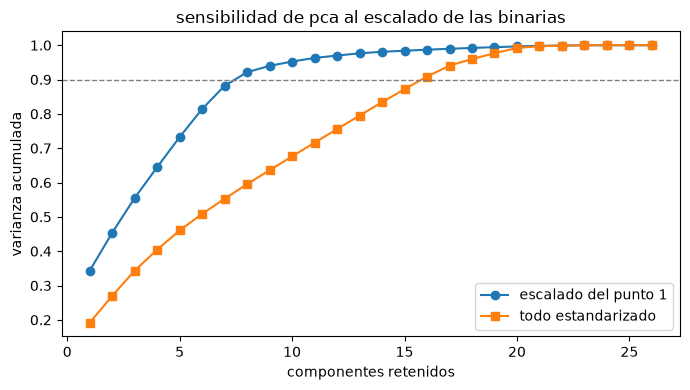

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o', label='escalado del punto 1')
plt.plot(range(1, len(var_acum_alt) + 1), var_acum_alt, marker='s', label='todo estandarizado')
plt.axhline(0.90, color='gray', linestyle='--', linewidth=1)
plt.xlabel('componentes retenidos')
plt.ylabel('varianza acumulada')
plt.title('sensibilidad de pca al escalado de las binarias')
plt.legend()
plt.tight_layout()
plt.show()

al estandarizar tambien las binarias el retrato cambia bastante, pc1 baja de 34,3 a 19,2 por ciento y para el 80 por ciento ya no bastan seis componentes sino catorce, con dieciseis para el 90, la difernecia sale de que las columnas de oficio y de resultado previo pasan a pesar lo mismo que las continuas y reparten varianza en muchas direcciones pequeñas.

el primer eje de esa version sigue liderado por el ciclo economico, con el euribor en 0,392, pero ahora entran poutcome_nonexistent con 0,363, previous con menos 0,349 y contactado_previamente con menos 0,253, o sea que el historial de campaña sube al eje principal en lugar de quedar diluido, y entra con signo contrario al del bloque macro, apartando a los clientes con historial de los periodos de euribor alto.

ninguna de las dos versiones es la correcta por decreto, la primera respeta el preprocesamiento acordado en el punto 1 y es la que se usa aqui, la segunda deja ver que la geometria depende del escalado elegido, y eso conviene tenerlo a mano al decidir el algoritmo del punto 3, si se quiere que el oficio pese en los grupos habria que escalar las binarias o pasar a un metodo pensado para variables mixtas como k prototypes.

2.6 lo que queda listo para el punto 3

se guardan los componentes que cubren 90 por ciento de la varianza en una tabla aparte, dejando x_cluster intacto para quien prefiera agrupar sobre las columnas originales.

In [36]:
# se retienen los componentes que cubren 90 por ciento de la varianza, insumo opcional del punto 3
pca_final = PCA(n_components=k90, random_state=42)
X_pca = pd.DataFrame(
    pca_final.fit_transform(X_pca_input),
    columns=['pc' + str(i) for i in range(1, k90 + 1)],
    index=X_cluster.index
)

print("forma de X_pca:", X_pca.shape)
print("varianza retenida:", round(pca_final.explained_variance_ratio_.sum(), 3))
X_pca.head()

forma de X_pca: (41176, 8)
varianza retenida: 0.921


,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8
0,1.366815,-2.509283,0.454804,0.223337,-0.576369,-0.019794,-0.248412,0.234411
1,1.295330,-1.227295,1.186982,0.374959,-0.293848,-0.122825,0.675337,0.357107
2,1.288110,0.026746,0.566955,0.255416,-0.618920,0.292315,-0.500879,0.366595
3,1.325844,-0.916700,0.262489,0.195438,-0.715553,0.275305,-0.836321,0.304535
4,1.294969,-1.164593,1.155981,0.368981,-0.310102,-0.102068,0.616527,0.357581


x_pca queda con 41176 filas y ocho columnas y retiene 92,1 por ciento de la varianza original, es el insumo que el punto 3 puede tomar directo si el algoritmo elegido sufre con 26 dimensiones, aunque nada obliga a usarlo, k means sobre x_cluster sigue siendo valido y hasta preferible cuando se quiera leer los centroides en las unidades originales.

lo que si conviene arrastrar son las tres advertencias, pc1 es calendario y no cliente, las binarias de oficio casi no pesan con el escalado actual, y la recencia imputada con la mediana quedo convertida en un eje propio, depsues de ver eso, un numero de grupos elegido solo por silueta sobre estos componentes va a premiar la particion por periodo, que es la mas separada geometricamente y la menos util en terminos comerciales.

### Punto 3

### Punto 4